<a href="https://colab.research.google.com/github/yc386/paasta_2026_denovo/blob/main/paasta_denovo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/PAASTA-community/paasta-community.github.io/blob/master/assets/media/paasta_no_bg.png?raw=1" width="180" height="85">
<img src="https://github.com/yc386/forked_pasta/blob/master/assets/media/summer_school.png?raw=1" width="460" height="80">


# *De novo* sequencing: from a PRIDE `.raw` file to annotated spectra

This is a 45-minute practical that walks you through the following:

1. **Fetch** a Thermo `.raw` file from the PRIDE FTP archive
2. **Convert** `.raw` → `mzML` with **ThermoRawFileParser**
3. **Parse** the `mzML` into a `parquet` for **InstaNovo** CLI and a `mgf` for their Hugging Face space
4. ***De Novo*** predict the spectra with **InstaNovo**
5. **Inspect** predictions and **annotate** spectra with its predicted b/y ions using **spectrum_utils**
6. **Score** predictions with label-free quality **metrics** (confidence & ion coverage)
7. *(optional, advanced)* **Calibrate** confidence and control **FDR** with **winnow**

> **Before you start:** set the GPU runtime — *Runtime → Change runtime type → Hardware accelerator → GPU (T4)*

>A Google account may be needed to run notebook cells. You may also click *File → Save a copy in Drive*.

>Our working directory(pwd) is /content/ (default), so no need to mount your own google drive unless you'd like to.

## Step 0 — Setup (run once; the runtime will restart)
**Don't click the prompt when Google asks you to restart, it will be done automatically!**
> When the runtime reconnects you'll see a **"Your session crashed for an unknown reason"** banner — don't be alarmed, that's just os.kill & restarting. The pip install cell is **safe to re-run** (it skips automatically if InstaNovo is already installed); just continue from the GPU check below.

In [ ]:
#@title pip install cell (takes c.5 mins; the runtime will restart automatically)
# Safe to re-run: if InstaNovo already imports, the whole setup is skipped.
try:
    import instanovo  # noqa: F401
    print("InstaNovo already installed - skipping setup. Continue from the GPU check below.")
except ImportError:
    # (ipywidgets -> clean tqdm progress bars; already present on Colab.)
    !pip install -q biopython "instanovo[cu126]>=1.2.2" pyteomics psims lxml polars pyarrow spectrum_utils ipywidgets

    # Colab pre-installs its own torch build, which clashes with the CUDA 12.6
    # wheels instanovo[cu126] needs. Force a known-good, matching CUDA 12.6 set.
    !pip uninstall -y torch torchvision torchaudio
    !pip install -q --no-cache-dir torch==2.6.0+cu126 torchvision==0.21.0+cu126 torchaudio==2.6.0+cu126 --index-url https://download.pytorch.org/whl/cu126

    print("Installation complete. Restarting runtime to apply changes...")
    import os
    os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of boto3 to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of boto3 to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━

Found existing installation: torch 2.8.0
Uninstalling torch-2.8.0:
  Successfully uninstalled torch-2.8.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 219.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 299.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 261.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 93.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 242.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 87.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 291.5

In [1]:
#@title >>> After the runtime restarts, start running from **HERE**. Check GPU available for InstaNovo[cu126]<<<
!nvidia-smi -L 2>/dev/null || echo "No GPU -> Runtime > Change runtime type > GPU"
import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
# Pin down exactly which InstaNovo / InstaNovo+ versions we're running (helps debugging)
!instanovo version

GPU 0: Tesla T4 (UUID: GPU-c2324d19-63e5-20e8-e6f9-3f08a71b654e)
torch: 2.6.0+cu126 | CUDA available: True
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Package    ┃ Version     ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ InstaNovo  │ 1.2.2       │
│ InstaNovo+ │ 1.2.2       │
│ NumPy      │ 2.4.6       │
│ PyTorch    │ 2.6.0+cu126 │
└────────────┴─────────────┘


## Step 1 — Fetch a .raw file from PRIDE

Every PRIDE project has a predictable FTP path:

```
https://ftp.pride.ebi.ac.uk/pride/data/archive/<year>/<month>/<accession>/
```
We are going to download a small file from [PXD058287](https://ftp.pride.ebi.ac.uk/pride/data/archive/2025/09/PXD058287/):
```
20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw (179.7 MB, downloading time: around 1 min)
```

In [2]:
import os, requests

ACCESSION = "PXD058287"
YEAR, MONTH = "2025", "09"
RAW_NAME = "20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw"
URL = f"https://ftp.pride.ebi.ac.uk/pride/data/archive/{YEAR}/{MONTH}/{ACCESSION}/{RAW_NAME}"
RAW_PATH = RAW_NAME

if not os.path.exists(RAW_PATH):
    print("Downloading", URL)
    with requests.get(URL, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(RAW_PATH, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
print("RAW size (MB):", round(os.path.getsize(RAW_PATH) / 1e6, 1))

RAW size (MB): 179.7


## Step 2 — Convert Thermo .raw → mzML
`.raw` is Thermo's vendor specific (closed) format. **[ThermoRawFileParser](https://github.com/compomics/ThermoRawFileParser)** is an open-source parser that runs on all platforms to convert `.raw` to open formats: `mzML`/`MGF`. We are using `v.2.0.0-dev` without `Mono` dependency.

The `-f` flag picks the **output format**:

| `-f` | format |
|------|--------|
| 0 | MGF |
| 1 | mzML (plain) |
| 2 | **indexed mzML** — *we use this* |
| 3 | Parquet |
| 4 | none (metadata only) |

We choose **`2` (indexed mzML)**: the embedded index lets a reader jump straight to any spectrum without scanning the whole file, so InstaNovo's `SpectrumDataFrame` loads it quickly. (Plain mzML in option 1 has the same data but no index.)

In [3]:
%%bash
# Skip the download/unzip if ThermoRawFileParser is already present.
if [ -f ThermoRawFileParser/ThermoRawFileParser ]; then
    echo "ThermoRawFileParser already present - skipping download."
else
    wget -q https://github.com/CompOmics/ThermoRawFileParser/releases/download/v.2.0.0-dev/ThermoRawFileParser-v.2.0.0-dev-linux.zip
    unzip -q ThermoRawFileParser-v.2.0.0-dev-linux.zip -d ThermoRawFileParser && rm ThermoRawFileParser-v.2.0.0-dev-linux.zip
    echo "ThermoRawFileParser downloaded."
fi

ThermoRawFileParser downloaded.


In [4]:
import os

# Reuse RAW_PATH from Step 1 so the filename lives in exactly one place.
# ThermoRawFileParser writes the .mzML next to the input with the same base name.
MZML_PATH = RAW_PATH.replace(".raw", ".mzML")
fmt = 2  # 0=MGF, 1=mzML (plain), 2=indexed mzML

# Skip the conversion if the .mzML already exists.
if os.path.exists(MZML_PATH):
    print(f"{MZML_PATH} already exists - skipping conversion.")
else:
    !ThermoRawFileParser/ThermoRawFileParser -i "{RAW_PATH}" -f "{fmt}" -z

=2026-06-09 17:18:10 INFO Started parsing 20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw
2026-06-09 17:18:11 INFO Processing 9917 MS scans
10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 

2026-06-09 17:18:26 INFO Finished parsing 20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T12_3.raw
2026-06-09 17:18:26 INFO Processing completed 0 errors, 0 warnings


## Step 3 — Parse the mzML
We are going to see what's inside a `mzML` by using InstaNovo's `SpectrumDataFrame`. `.parquet` is like a `.csv` but smaller to store and faster for a computer to process.

In [5]:
import glob
import pandas as pd
from instanovo.utils.data_handler import SpectrumDataFrame

sdf1 = SpectrumDataFrame.load(MZML_PATH, lazy=False, is_annotated=False)
df = sdf1.to_pandas()
print(f"Parsed {len(df)} spectra | columns: {list(df.columns)}")
df.head()  # show a preview, not all rows (the mz/intensity arrays are large)

/usr/local/lib/python3.12/dist-packages/psims/mzmlb/writer.py:33: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


Parsed 8853 spectra | columns: ['scan_number', 'sequence', 'precursor_mass', 'precursor_mz', 'precursor_charge', 'retention_time', 'mz_array', 'intensity_array', 'experiment_name']


,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array,experiment_name
0,6,,1705.768895,853.891724,2,0.036581,"[115.26212310791016, 120.08121490478516, 138.7...","[1531.368896484375, 3489.806884765625, 1258.18...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
1,7,,948.534520,475.274536,2,0.038742,"[165.88584899902344, 209.11793518066406, 263.7...","[1227.3123779296875, 1877.300537109375, 1068.0...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
2,8,,1722.797826,862.406189,2,0.040933,"[126.2745361328125, 141.3558807373047, 203.858...","[1408.305908203125, 1389.77490234375, 1384.296...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
3,10,,946.509191,474.261871,2,0.048800,"[140.41928100585938, 163.00881958007812, 164.8...","[1225.0076904296875, 1150.8607177734375, 1249....",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...
4,11,,1316.515007,439.845612,3,0.050944,"[197.87615966796875, 217.11524963378906, 217.1...","[1342.667724609375, 2023.048828125, 2312.31445...",20240425-2151_QEHF3_1007093_ONJ_TR_MC_BLG_LS_T...


For this workshop we select a **subset of 100 spectra** to keep runtimes short.

Rather than the first 100 scans — which elute early and are mostly low quality — we take **charge 2–3** precursors as a **mix of the 50 most intense + 50 random** spectra. The most-intense alone are dominated by a few very abundant peptides (lots of duplicates); adding a random half gives **diverse peptides and a spread of confidence** (some easy, some hard) — useful for the metrics and FDR steps later.

In [ ]:
import numpy as np

# The first scans elute early and are mostly low quality. Instead, build a
# 100-spectrum subset with a MIX of quality, for diverse peptides AND a spread
# of confidence: the most-intense (top-TIC) spectra alone are dominated by a
# few very abundant peptides (lots of duplicates). Keep charge 2-3 (best for
# de novo); take 50 most intense + 50 random.
dfq = df[df["precursor_charge"].isin([2, 3])].copy()
dfq["_tic"] = dfq["intensity_array"].map(lambda a: float(np.sum(a)))
top  = dfq.sort_values("_tic", ascending=False).head(50)
rand = dfq.drop(top.index).sample(n=50, random_state=0)   # random_state -> reproducible
df1  = (pd.concat([top, rand]).drop(columns="_tic")
          .sample(frac=1, random_state=0)                 # shuffle so it isn't quality-sorted
          .reset_index(drop=True))
print(f"selected {len(df1)} spectra: 50 most intense + 50 random (charge 2-3) | median peaks/spectrum: {int(df1['mz_array'].map(len).median())}")

selected 100 spectra: 50 most intense + 50 random (charge 2-3) | median peaks/spectrum: 137


In [7]:
from pyteomics import mgf
import numpy as np

def df_to_mgf(df, out_path):
    spectra = []
    for _, row in df.iterrows():
        params = {
            "title":       f"{row['experiment_name']}:scan:{int(row['scan_number'])}",
            "pepmass":     float(row["precursor_mz"]),
            "charge":      f"{int(row['precursor_charge'])}+",
            "rtinseconds": float(row["retention_time"]) * 60.0,
            "scans":       int(row["scan_number"]),
        }
        seq = row.get("sequence")
        if seq is not None and str(seq).strip() not in ("", "nan", "None"):
            params["seq"] = str(seq)

        spectra.append({
            "m/z array":       np.asarray(row["mz_array"],        dtype=float),
            "intensity array": np.asarray(row["intensity_array"], dtype=float),
            "params":          params,
        })

    mgf.write(spectra, out_path, file_mode="w")
    return f"Converted dataframe to MGF file: {out_path}"

We then write our subset to both `.parquet` (for the CLI) and `.mgf` (for the Hugging Face space).

In [ ]:
df1.to_parquet("subset_100.parquet")
print("Converted dataframe to parquet file: subset_100.parquet")
print(df_to_mgf(df1, "subset_100.mgf"))

'Converted dataframe to MGF file: head_100.mgf'

## Step 4 — Run InstaNovo for *de novo*
**[InstaNovo](https://github.com/instadeepai/InstaNovo)** is a transformer model that is well-annotated and easy to run. We run it to get a peptide sequence per spectrum, written to `preds.csv` (columns include `predictions`, the sequence confidence `log_probs`, per-residue `token_log_probs`, and beam-search columns).
>
- option A: For Google account users, you may run it here using the CLI (command line interface).
- option B: Go to InstaNovo [Hugging Face space](https://huggingface.co/spaces/InstaDeepAI/InstaNovo) and run the `subset_100.mgf` we made in Step 3 online. <br />(note **not the `.mzML`** since it may be too big)

> InstaNovo also ships **InstaNovo+**, a diffusion model that *refines* the transformer output (`instanovo predict ... --with-refinement`). We skip it here to keep the workshop fast; see the [InstaNovo getting-started notebook](https://github.com/instadeepai/InstaNovo/blob/main/notebooks/getting_started_with_instanovo.ipynb) to try it.

In [9]:
!instanovo predict --help

                                                                                
 Usage: instanovo predict [OPTIONS] [OVERRIDES]...                              
                                                                                
 Run predictions with InstaNovo and optionally refine with InstaNovo+.          
                                                                                
 First with the transformer-based InstaNovo model and then optionally refine    
 them with the diffusion based InstaNovo+ model.                                
                                                                                
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --data-path             -d                      TEXT  Path to input data     │
│                                                       file                   │
│ --output-path           -o                      FILE  Path to output file.   │
│ --instanovo-model       -i

In [ ]:
# Run the transformer model for de novo sequencing.
# (--no-refinement: skip the InstaNovo+ diffusion step to keep the workshop fast.)
!instanovo predict --data-path subset_100.parquet --output-path preds.csv --denovo --no-refinement

[06/09/26 17:19:04] INFO     Initializing InstaNovo inference.                                                                                                                 
[06/09/26 17:19:07] INFO     NumExpr defaulting to 2 threads.                                                                                                                  
2026-06-09 17:19:12.653337: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-06-09 17:19:15,154:jax._src.path:41: etils.epath found. Using etils.epath for file I/O.
/usr/local/lib/python3.12/dist-packages/psims/mzmlb/writer.py:33: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


## Step 5 — Inspect predictions and annotate spectra
We will pick *de novo* predictions from a list of top and bottom 10 spectra (sorted by model confidence), and visualise them using mirrored plots to see if observed b/y ions matched predicted ones. Generally, higher the ion coverage (observed/predicted ions), the better.

This is *real* data with **no ground-truth peptide labels**, so we can't compute recall/precision — we use confidence and b/y ion coverage as quality proxies instead (quantified in Step 6).

In [11]:
import matplotlib.pyplot as plt
import spectrum_utils.spectrum as sus
import spectrum_utils.plot as sup
from spectrum_utils import proforma
from spectrum_utils.fragment_annotation import get_theoretical_fragments
%matplotlib inline

==TOP 10 (most confident)==
 scan_number predictions  log_probs  model_confidence
        2166    LIVTQTMK  -0.000084          0.999916
        2238    LIVTQTMK  -0.000133          0.999867
        2251    LIVTQTMK  -0.000151          0.999849
        2178    LIVTQTMK  -0.000157          0.999843
        2091    LIVTQTMK  -0.000205          0.999795
        2264    LIVTQTMK  -0.000213          0.999787
        2212    LIVTQTMK  -0.000226          0.999774
        2143    LIVTQTMK  -0.000277          0.999723
        2290    LIVTQTMK  -0.000286          0.999714
        2277    LIVTQTMK  -0.000446          0.999555

==BOTTOM 10 (least confident)==
 scan_number                             predictions  log_probs  model_confidence
        9532                  YVLQLLVTKPGEDFAVAEALTK -13.774187      1.042189e-06
        5570                 KLLAEKYTKLPAVFKLDALNENK -13.990720      8.392814e-07
        8457    [UNIMOD:1]-GSFNPGGAHEEQC[UNIMOD:4]HI -14.446985      5.318070e-07
        6372     

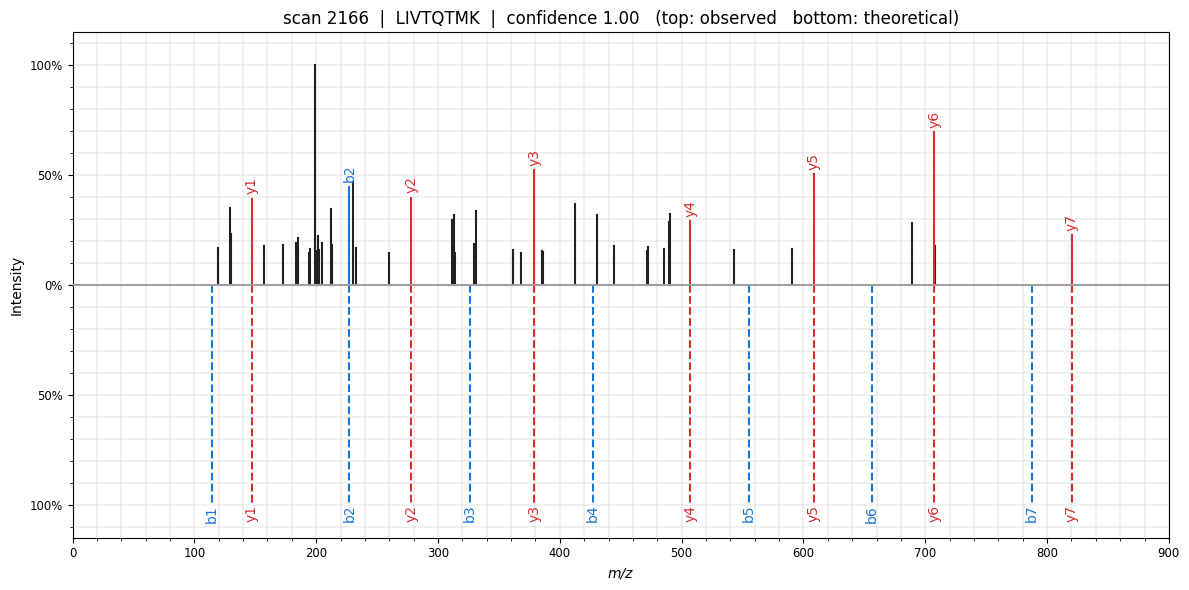

In [ ]:
PARQUET = "subset_100.parquet"
#change fragment ion tolerance here
TOL, TOL_MODE = 10, "ppm"

preds   = pd.read_csv("preds.csv")
spectra = pd.read_parquet(PARQUET)

seq_col  = next((c for c in ["predictions","prediction","sequence","peptide"] if c in preds.columns), preds.columns[0])
conf_col = next((c for c in ["log_probs","log_probabilities","confidence"] if c in preds.columns), None)
if conf_col is not None:
    preds["model_confidence"] = np.clip(np.exp(preds[conf_col]), 0, 1)

cand = preds.sort_values(conf_col, ascending=False) if conf_col else preds
cols = ["scan_number", seq_col, conf_col, "model_confidence"]

print("==TOP 10 (most confident)==")
print(cand[cols].head(10).to_string(index=False))

print("\n==BOTTOM 10 (least confident)==")
print(cand[cols].tail(10).to_string(index=False))

In [ ]:
def show_mirror(scan_number=None):
    """Pass a scan_number from the list above; None = highest confidence."""
    if scan_number is None:
        row = cand.iloc[0]
    else:
        sel = cand[cand["scan_number"] == scan_number]
        if sel.empty:
            print(f"scan {scan_number} not found in predictions - pick one from the lists above.")
            return
        row = sel.iloc[0]
    peptide, scan = str(row[seq_col]), int(row["scan_number"])
    conf = float(row["model_confidence"]) if "model_confidence" in row else None
    sp = spectra.loc[spectra["scan_number"] == scan].iloc[0]
    pmz, z = float(sp["precursor_mz"]), int(sp["precursor_charge"])

    obs = sus.MsmsSpectrum(str(scan), pmz, z,
                           np.asarray(sp["mz_array"], float), np.asarray(sp["intensity_array"], float))
    obs = (obs.set_mz_range(100, 1500).remove_precursor_peak(TOL, TOL_MODE)
              .filter_intensity(0.01, 50).scale_intensity("root")
              .annotate_proforma(peptide, TOL, TOL_MODE, ion_types="by"))

    proteoform = proforma.parse(peptide)[0]
    frags = get_theoretical_fragments(proteoform, ion_types="by", max_charge=1)
    frag_mz = np.array([mz for _, mz in frags])
    theo = sus.MsmsSpectrum(f"{peptide} (theoretical)", pmz, z,
                            frag_mz, np.full(len(frag_mz), obs.intensity.max()))
    theo = theo.annotate_proforma(peptide, TOL, TOL_MODE, ion_types="by")

    fig, ax = plt.subplots(figsize=(12, 6))
    sup.mirror(obs, theo, ax=ax)

    # Restyle the lower (theoretical, negative-y) half of the mirror plot as
    # dashed lines. This pokes at matplotlib artists directly, so it may need
    # updating if spectrum_utils / matplotlib change how they draw peaks.
    for line in ax.lines:
        yd = line.get_ydata()
        if len(yd) and np.min(yd) < -1e-9:
            line.set_linestyle("--")
    for coll in ax.collections:
        segs = coll.get_segments()
        if segs and min(s[:, 1].min() for s in segs) < -1e-9:
            coll.set_linestyle("--")

    conf_str = f"  |  confidence {conf:.2f}" if conf is not None else ""
    ax.set_title(f"scan {scan}  |  {peptide}{conf_str}   (top: observed   bottom: theoretical)")
    plt.tight_layout(); plt.show()

# highest-confidence prediction
show_mirror()

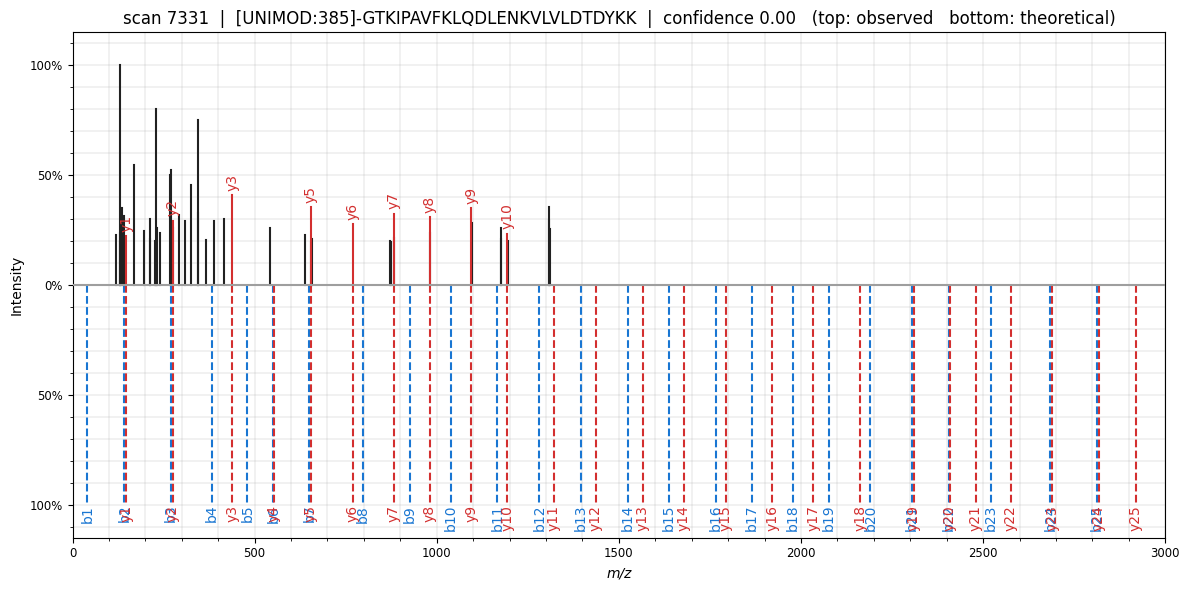

In [13]:
# show_mirror() above used the most-confident prediction. You can pass any
# scan_number from the TOP/BOTTOM lists above. Scan numbers depend on the
# (random) subset, so here we pick the LEAST-confident one to contrast.
show_mirror(int(cand.iloc[-1]["scan_number"]))

Show the first few predictions.

In [3]:
preds.head()

NameError: name 'preds' is not defined

## Step 6 — Quality metrics without ground truth
This is real data with **no known peptides**, so we can't compute recall/precision. Instead we use two **label-free** signals:
- **model confidence** = `exp(log_probs)` of the prediction — how sure the model is.
- **ion coverage** = fraction of the predicted peptide's theoretical **b/y** ions actually observed in the spectrum — how well the prediction explains the data.

A trustworthy identification has **both** high confidence *and* high ion coverage.
> Our Step 3 subset deliberately mixes high-quality and random spectra, so you'll see a **spread**: confident, well-covered hits alongside poor ones. Watch for the disagreements — **high confidence with low coverage is a red flag**, and is exactly what confidence-calibration / FDR-control tools (e.g. [winnow](https://github.com/instadeepai/winnow), see later) are built to catch.

model confidence : mean 0.58  median 0.81
ion coverage     : mean 0.46  median 0.50


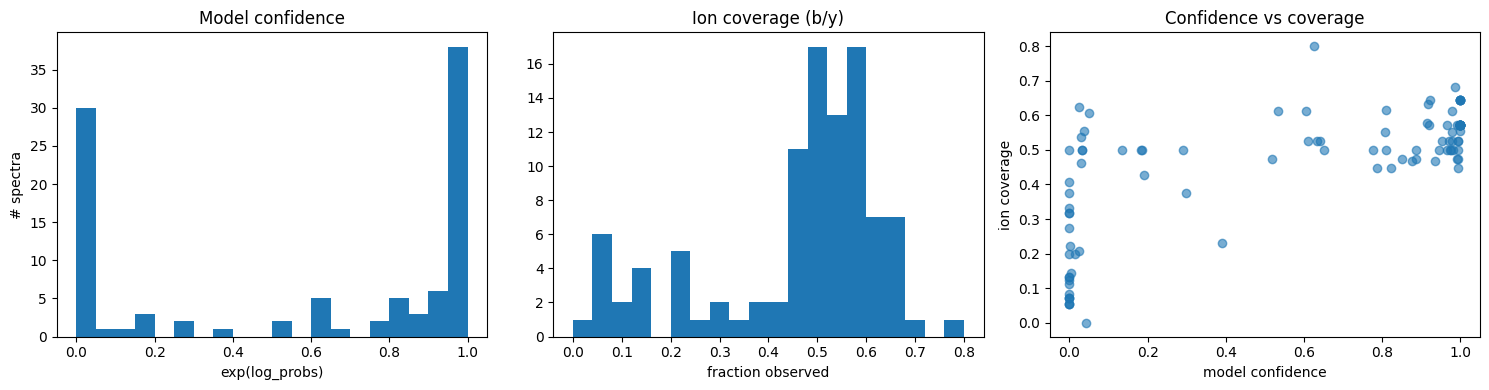

In [ ]:
#@title Confidence & ion coverage (reuses spectrum_utils imports from Step 5)
preds   = pd.read_csv("preds.csv")
spectra = pd.read_parquet("subset_100.parquet")
TOL = 10  # ppm, fragment match tolerance

preds["model_confidence"] = np.clip(np.exp(preds["log_probs"]), 0, 1)

def ion_coverage(peptide, mz_array, tol_ppm=TOL):
    """Fraction of theoretical singly-charged b/y ions observed in the spectrum."""
    try:
        prot = proforma.parse(str(peptide))[0]
        frags = get_theoretical_fragments(prot, ion_types="by", max_charge=1)
    except Exception:
        return np.nan
    obs = np.asarray(mz_array, float)
    if not frags or obs.size == 0:
        return np.nan
    matched = sum(np.min(np.abs(obs - t)) / t * 1e6 <= tol_ppm for _, t in frags)
    return matched / len(frags)

mz_by_scan = {int(r["scan_number"]): r["mz_array"] for _, r in spectra.iterrows()}
preds["ion_coverage"] = [ion_coverage(p, mz_by_scan.get(int(s)))
                         for p, s in zip(preds["predictions"], preds["scan_number"])]

print("model confidence : mean %.2f  median %.2f" % (preds["model_confidence"].mean(), preds["model_confidence"].median()))
print("ion coverage     : mean %.2f  median %.2f" % (preds["ion_coverage"].mean(), preds["ion_coverage"].median()))

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(preds["model_confidence"], bins=20); ax[0].set(title="Model confidence", xlabel="exp(log_probs)", ylabel="# spectra")
ax[1].hist(preds["ion_coverage"].dropna(), bins=20); ax[1].set(title="Ion coverage (b/y)", xlabel="fraction observed")
ax[2].scatter(preds["model_confidence"], preds["ion_coverage"], alpha=0.6); ax[2].set(title="Confidence vs coverage", xlabel="model confidence", ylabel="ion coverage")
plt.tight_layout(); plt.show()

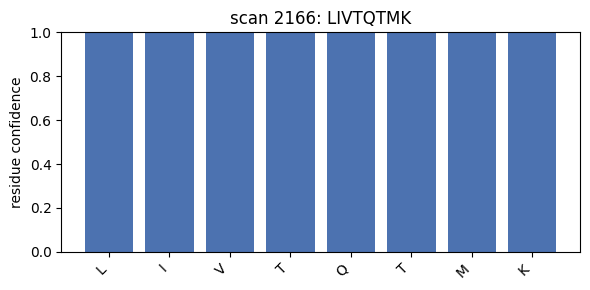

In [16]:
#@title Per-residue confidence
# InstaNovo reports a per-residue confidence (token log-probability); low-confidence
# residues are where the model is unsure (often where errors or isobaric swaps happen).
import ast

def show_residue_confidence(scan_number):
    row = preds.loc[preds["scan_number"] == scan_number]
    if row.empty:
        print(f"scan {scan_number} not found - pick one from the lists above.")
        return
    row = row.iloc[0]
    tokens = [t.strip() for t in str(row["predictions_tokenised"]).split(",")]
    tlp = np.asarray(ast.literal_eval(row["token_log_probs"]), float)
    conf = np.exp(tlp[:len(tokens)])
    fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(tokens)), 3))
    ax.bar(range(len(tokens)), conf, color="#4C72B0")
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("residue confidence")
    ax.set_title(f"scan {scan_number}: {''.join(tokens)}")
    plt.tight_layout(); plt.show()

# most confident prediction
show_residue_confidence(int(preds.sort_values("model_confidence", ascending=False).iloc[0]["scan_number"]))

In [ ]:
# least confident prediction
show_residue_confidence(int(preds.sort_values("model_confidence", ascending=False).iloc[-1]["scan_number"]))

## Step 7 Calibrate confidence & control FDR with winnow
The model's `log_probs` confidence isn't *calibrated* — a score of 0.9 doesn't literally mean "90% likely correct". [**Winnow**](https://github.com/instadeepai/winnow) recalibrates *de novo* confidence with a **pretrained general model** and estimates a **false discovery rate (FDR)** *without ground-truth labels*, so you can keep only PSMs below a chosen FDR.

> **Heads-up:**
> - Needs **internet**: it downloads a pretrained calibrator from Hugging Face and queries the public **[Koina](https://koina.wilhelmlab.org)** server for fragment-ion predictions.
> - We install winnow from its **`revisions`** branch for now (the released PyPI build can't yet load the current safetensors model). **Revert to `pip install winnow-fdr` once the open PRs are merged.**
> - The winnow install upgrades `torch` (it needs `torch>=2.10`), which can break `instanovo`. That's fine here — Step 7 reuses the `preds.csv` from Step 4 and doesn't call InstaNovo again.

In [17]:
#@title Install winnow (confidence calibration & FDR control)
# Run this AFTER the transformer prediction above: winnow needs torch>=2.10, so
# installing it upgrades torch and would break `instanovo predict` if run first.
# Installing from the `revisions` branch: the published winnow-general-model
# (safetensors format) needs loader updates not yet in the PyPI release.
# TODO: revert to `!pip install -q winnow-fdr` once the outstanding PRs are merged.
!pip install -q "winnow-fdr @ git+https://github.com/instadeepai/winnow.git@revisions"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.4/833.4 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 44.2 MB

In [ ]:
#@title Load predictions into winnow, then calibrate confidence
import os, warnings, winnow
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hydra import initialize_config_dir, compose
from hydra.utils import instantiate
from winnow.calibration.calibrator import ProbabilityCalibrator
from winnow.fdr.nonparametric import NonParametricFDRControl

# winnow merges predictions with spectra on spectrum_id (= experiment_name:scan_number)
sp = pd.read_parquet("subset_100.parquet")
sp["spectrum_id"] = sp["experiment_name"].astype(str) + ":" + sp["scan_number"].astype(str)
sp.to_parquet("subset_100_winnow.parquet")

# Build the InstaNovo data loader from winnow's packaged config
WINNOW_CFG = os.path.join(os.path.dirname(winnow.__file__), "configs")
with initialize_config_dir(config_dir=WINNOW_CFG, version_base="1.3", job_name="paasta"):
    cfg = compose(config_name="train")
loader = instantiate(cfg.data_loader)
dataset = loader.load(data_path="subset_100_winnow.parquet", predictions_path="preds.csv")
print("loaded", len(dataset), "PSMs")

loaded 100 PSMs


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Prosit_2025_intensity_22PTM::   0%|          | 0/1 [00:00<?, ?it/s]

Prosit_2025_irt_22PTM::   0%|          | 0/1 [00:00<?, ?it/s]

Prosit_2025_irt_22PTM::   0%|          | 0/1 [00:00<?, ?it/s]

count    97.000000
mean      0.635102
std       0.384620
min       0.000030
25%       0.283371
50%       0.834462
75%       0.958112
max       0.979688
Name: calibrated_confidence, dtype: float64


The pretrained calibrator's Prosit fragment model needs a per-spectrum collision energy and fragmentation type, which aren't in the mzML metadata.
For this run (Q Exactive HF, HCD) the normalized collision energy (NCE) is ~30.
Set these parameters to your acquisition's normalized collision energy for the most accurate fragment-match features.

In [ ]:
dataset.metadata["collision_energy"] = 30
dataset.metadata["frag_type"] = "HCD"

# Pretrained general calibrator — no training or labels needed
calibrator = ProbabilityCalibrator.load()  # downloads from HuggingFace
# Fragment-match features query the public Koina server (needs internet)
calibrator.apply_koina_server_overrides(server_url="koina.wilhelmlab.org:443", ssl=True)
calibrator.compute_features(dataset)
calibrator.predict(dataset)  # adds dataset.metadata["calibrated_confidence"]
print(dataset.metadata["calibrated_confidence"].describe())

5% FDR -> calibrated-confidence cutoff 0.865
10% FDR -> calibrated-confidence cutoff 0.697
25% FDR -> calibrated-confidence cutoff 0.015
PSMs passing 5% FDR: 44


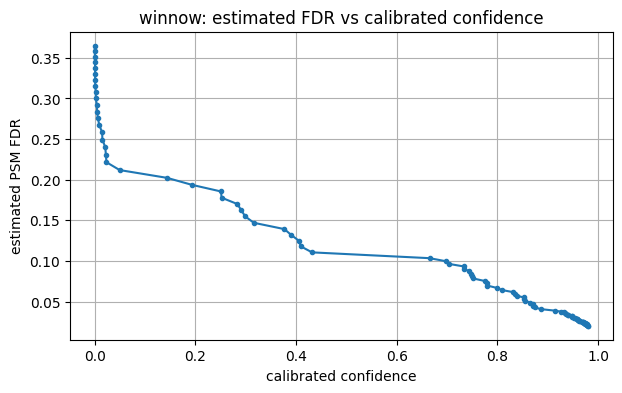

In [ ]:
#@title Estimate FDR from the calibrated confidence (label-free)
fdr = NonParametricFDRControl()
fdr.fit(dataset.metadata["calibrated_confidence"])
md = fdr.add_psm_fdr(dataset.metadata, confidence_col="calibrated_confidence")
md = fdr.add_psm_q_value(md, confidence_col="calibrated_confidence")

for thr in (0.05, 0.10, 0.25):
    try:
        print(f"{int(thr*100)}% FDR -> calibrated-confidence cutoff {fdr.get_confidence_cutoff(thr):.3f}")
    except Exception:
        print(f"{int(thr*100)}% FDR -> not reachable on this small, low-quality subset")
print("PSMs passing 5% FDR:", int((md["psm_q_value"] <= 0.05).sum()))

In [ ]:
o = md.sort_values("calibrated_confidence")
plt.figure(figsize=(7, 4))
plt.plot(o["calibrated_confidence"], o["psm_fdr"], marker=".")
plt.xlabel("calibrated confidence"); plt.ylabel("estimated PSM FDR")
plt.title("winnow: estimated FDR vs calibrated confidence"); plt.grid(True); plt.show()

### Reading the FDR curve
The curve is **monotonic**: higher calibrated confidence → lower estimated FDR. To control the false discovery rate you pick a target and keep only PSMs **above the matching confidence cutoff**:
- **5% FDR** needs calibrated confidence ≈ **0.87** here → about **44 / 100** PSMs pass.
- relaxing to **10%** drops the cutoff (≈ 0.70) and keeps more; **25%** keeps almost everything.

This is the **precision/recall trade-off made explicit**: a stricter FDR keeps fewer but higher-quality identifications. The key win is that it works **without ground-truth labels** — after calibration the confidence behaves like a real probability of being correct, so "5% FDR" means roughly 5% of the *kept* PSMs are expected to be wrong. For downstream analysis you'd report only the FDR-filtered subset (e.g. the ~44 PSMs at 5% FDR), not all 100 raw predictions.

> ⚠️ The estimate is only as trustworthy as its inputs: a **generic** pretrained calibrator, an **approximate** collision energy, and the non-parametric method's assumption that the calibrated scores really are well-calibrated. Treat the exact cutoffs as indicative, and re-calibrate on your own instrument/data for production use.